# Unit06 Example 01 - 液體摻合問題

## 學習目標

在本範例中，我們將探討化工製程中常見的液體摻合問題。透過建立物料平衡方程式，將實際化工問題轉化為線性聯立方程組，並應用 NumPy 與 SciPy 的求解工具來計算各儲存槽的所需用量。

學習完本範例後，您將能夠：

- 建立多成分液體摻合的物料平衡方程式
- 將化工問題轉化為標準矩陣形式 $\mathbf{Ax} = \mathbf{b}$
- 使用 `numpy.linalg.lstsq()` 與 `scipy.linalg.lstsq()` 求解
- 驗證解的唯一性與正確性（秩判定、質量守恆檢查）
- 解釋解的物理意義與實際應用

## 內容大綱

1. 環境設定與套件載入
2. 問題描述與數學模型建立
3. NumPy 求解方法
4. SciPy 求解方法
5. 結果驗證與分析
6. 視覺化呈現
7. 總結

---
## 1. 環境設定與套件載入

In [1]:
# 基礎套件
import numpy as np
import matplotlib.pyplot as plt

# SciPy 線性代數模組
from scipy import linalg

# 設定 NumPy 顯示選項
np.set_printoptions(precision=4, suppress=True)

# 設定 Matplotlib 繪圖樣式
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.unicode_minus'] = False  # 修正負號顯示

print("="*60)
print("環境設定與套件載入")
print("="*60)
print(f"NumPy 版本: {np.__version__}")
import scipy
print(f"SciPy 版本: {scipy.__version__}")
print("="*60)

環境設定與套件載入
NumPy 版本: 1.23.5
SciPy 版本: 1.15.2


---
## 2. 問題描述與數學模型建立

### 2.1 化工情境

某化工廠生產特殊配方的液體產品，需要從三個不同的儲存槽中取出原料進行摻合。每個儲存槽中的液體含有三種成分（A、B、C），但各槽的成分比例不同。

**儲存槽組成資料**：

| 槽號 | 成分 A (wt%) | 成分 B (wt%) | 成分 C (wt%) |
|------|-------------|-------------|-------------|
| 槽 1 | 50 | 30 | 20 |
| 槽 2 | 20 | 60 | 20 |
| 槽 3 | 30 | 10 | 60 |

**生產目標**：

- 目標產品總重量：100 kg
- 目標產品組成：成分 A：35 wt%（35 kg）、成分 B：35 wt%（35 kg）、成分 C：30 wt%（30 kg）

**求解問題**：需要從各槽取出多少重量的液體（ $V_1, V_2, V_3$ ），才能混合出符合目標組成的產品？

In [2]:
# 問題定義
print("="*60)
print("液體摻合問題")
print("="*60)

# 各槽組成（重量百分比 → 小數）
tank_compositions = {
    1: {'A': 0.50, 'B': 0.30, 'C': 0.20},
    2: {'A': 0.20, 'B': 0.60, 'C': 0.20},
    3: {'A': 0.30, 'B': 0.10, 'C': 0.60}
}

# 目標產品
target_total = 100  # kg
target_composition = {'A': 35, 'B': 35, 'C': 30}  # kg

print("\n各儲存槽組成:")
for tank_id, comp in tank_compositions.items():
    print(f"槽 {tank_id}: A={comp['A']*100:.0f}%, B={comp['B']*100:.0f}%, C={comp['C']*100:.0f}%")

print(f"\n目標產品 ({target_total} kg):")
for component, amount in target_composition.items():
    print(f"成分 {component}: {amount} kg ({amount/target_total*100:.0f}%)")

液體摻合問題

各儲存槽組成:
槽 1: A=50%, B=30%, C=20%
槽 2: A=20%, B=60%, C=20%
槽 3: A=30%, B=10%, C=60%

目標產品 (100 kg):
成分 A: 35 kg (35%)
成分 B: 35 kg (35%)
成分 C: 30 kg (30%)


---
## 2. 數學模型建立

### 2.1 物料平衡方程式

根據質量守恆定律，對於每一個成分，其在產品中的總量等於各槽貢獻量的總和。

**成分 A 的物料平衡**：

$$
0.50 V_1 + 0.20 V_2 + 0.30 V_3 = 35
$$

**成分 B 的物料平衡**：

$$
0.30 V_1 + 0.60 V_2 + 0.10 V_3 = 35
$$

**成分 C 的物料平衡**：

$$
0.20 V_1 + 0.20 V_2 + 0.60 V_3 = 30
$$

**總質量守恆**：

$$
V_1 + V_2 + V_3 = 100
$$

### 2.2 矩陣形式表示

將上述方程式整理為標準的線性聯立方程組 $\mathbf{Ax} = \mathbf{b}$ ：

- **係數矩陣** $\mathbf{A}$  （4×3）：包含各槽各成分的比例係數
- **未知數向量** $\mathbf{x}$  （3×1）：各槽的取用量 $(V_1, V_2, V_3)$
- **常數向量** $\mathbf{b}$  （4×1）：目標產品的成分量與總量

### 2.3 系統類型

- 方程式數量 $m = 4$ ，未知數數量 $n = 3$
- 這是**過確定系統** (overdetermined system)，因為 $m > n$
- 需檢查秩來判斷系統是否相容

In [3]:
# 建立係數矩陣 A 與常數向量 b
print("="*60)
print("建立線性方程組")
print("="*60)

# 係數矩陣 A (4×3)
A = np.array([
    [0.50, 0.20, 0.30],  # 成分 A 的物料平衡
    [0.30, 0.60, 0.10],  # 成分 B 的物料平衡
    [0.20, 0.20, 0.60],  # 成分 C 的物料平衡
    [1.00, 1.00, 1.00]   # 總質量守恆
])

# 常數向量 b (4×1)
b = np.array([35, 35, 30, 100])

print("\n係數矩陣 A (4×3):")
print(A)
print(f"\n矩陣形狀: {A.shape}")

print("\n常數向量 b (4×1):")
print(b)
print(f"\n向量形狀: {b.shape}")

print(f"\n系統類型: 過確定系統 (m={A.shape[0]} > n={A.shape[1]})")

建立線性方程組

係數矩陣 A (4×3):
[[0.5 0.2 0.3]
 [0.3 0.6 0.1]
 [0.2 0.2 0.6]
 [1.  1.  1. ]]

矩陣形狀: (4, 3)

常數向量 b (4×1):
[ 35  35  30 100]

向量形狀: (4,)

系統類型: 過確定系統 (m=4 > n=3)


---
## 3. 秩分析與解的存在性

### 3.1 秩判定準則

對於過確定系統 $\mathbf{Ax} = \mathbf{b}$ ，解的存在性取決於：

- 若 $\mathrm{rank}(\mathbf{A}) = \mathrm{rank}([\mathbf{A} \mid \mathbf{b}])$ ：系統**相容**，存在解
- 若 $\mathrm{rank}(\mathbf{A}) < \mathrm{rank}([\mathbf{A} \mid \mathbf{b}])$ ：系統**不相容**，無精確解

進一步判斷解的唯一性：

- 若 $\mathrm{rank}(\mathbf{A}) = n$  （未知數個數） ：有**唯一解**
- 若 $\mathrm{rank}(\mathbf{A}) < n$ ：有**無窮多組解**

### 3.2 擴增矩陣

擴增矩陣 $[\mathbf{A} \mid \mathbf{b}]$ 是將常數向量 $\mathbf{b}$ 附加到係數矩陣 $\mathbf{A}$ 右側形成的矩陣。

In [4]:
# 秩分析
print("="*60)
print("秩分析")
print("="*60)

# 計算係數矩陣的秩
rank_A = np.linalg.matrix_rank(A)

# 建立擴增矩陣 [A|b]
A_augmented = np.column_stack([A, b])
rank_Ab = np.linalg.matrix_rank(A_augmented)

print(f"\nrank(A) = {rank_A}")
print(f"rank([A|b]) = {rank_Ab}")
print(f"未知數個數 n = {A.shape[1]}")

print("\n擴增矩陣 [A|b] (4×4):")
print(A_augmented)

# 判斷系統相容性與解的唯一性
print("\n" + "-"*60)
if rank_A == rank_Ab:
    print("✓ 系統相容（rank(A) = rank([A|b])）")
    if rank_A == A.shape[1]:
        print(f"✓ 有唯一解（rank(A) = n = {A.shape[1]}）")
    else:
        print(f"⚠ 有無窮多組解（rank(A) = {rank_A} < n = {A.shape[1]}）")
else:
    print("✗ 系統不相容（rank(A) < rank([A|b])）")
    print("  僅能求最小平方解")
print("-"*60)

秩分析

rank(A) = 3
rank([A|b]) = 3
未知數個數 n = 3

擴增矩陣 [A|b] (4×4):
[[  0.5   0.2   0.3  35. ]
 [  0.3   0.6   0.1  35. ]
 [  0.2   0.2   0.6  30. ]
 [  1.    1.    1.  100. ]]

------------------------------------------------------------
✓ 系統相容（rank(A) = rank([A|b])）
✓ 有唯一解（rank(A) = n = 3）
------------------------------------------------------------


---
## 4. NumPy 求解方法

### 4.1 使用 np.linalg.lstsq() 求解

由於這是過確定系統，我們使用 `numpy.linalg.lstsq()` 函數來求解。此函數會找到使殘差平方和 $\|\mathbf{Ax} - \mathbf{b}\|^2$ 最小的解。

**函數語法**：
```python
x, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
```

**返回值說明**：
- `x`：最小平方解
- `residuals`：殘差平方和（僅當 $m > n$ 且 $\mathrm{rank}(\mathbf{A}) = n$ 時返回）
- `rank`：矩陣 $\mathbf{A}$ 的秩
- `s`：矩陣 $\mathbf{A}$ 的奇異值

In [5]:
# NumPy 求解
print("="*60)
print("NumPy 最小平方求解")
print("="*60)

# 使用 lstsq 求解
result = np.linalg.lstsq(A, b, rcond=None)
V_numpy = result[0]
residuals_numpy = result[1]
rank_numpy = result[2]
singular_values = result[3]

print("\n求解結果:")
print(f"槽 1 用量 (V1): {V_numpy[0]:.4f} kg")
print(f"槽 2 用量 (V2): {V_numpy[1]:.4f} kg")
print(f"槽 3 用量 (V3): {V_numpy[2]:.4f} kg")
print(f"總計: {V_numpy.sum():.4f} kg")

print(f"\n矩陣秩: {rank_numpy}")
print(f"奇異值: {singular_values}")

if len(residuals_numpy) > 0:
    print(f"\n殘差平方和: {residuals_numpy[0]:.2e}")
    if residuals_numpy[0] < 1e-20:
        print("✓ 殘差接近零，系統有精確解")
else:
    print("\n未返回殘差（可能因為 m ≤ n 或 rank < n）")

NumPy 最小平方求解

求解結果:
槽 1 用量 (V1): 41.6667 kg
槽 2 用量 (V2): 33.3333 kg
槽 3 用量 (V3): 25.0000 kg
總計: 100.0000 kg

矩陣秩: 3
奇異值: [2.     0.4606 0.2606]

殘差平方和: 1.54e-30
✓ 殘差接近零，系統有精確解


---
## 5. SciPy 求解方法與結果比較

### 5.1 使用 scipy.linalg.lstsq() 求解

SciPy 也提供了 `lstsq()` 函數，功能類似 NumPy 但提供更多控制選項與數值穩定性優化。

### 5.2 NumPy 與 SciPy 的差異

- **NumPy**：基於 LAPACK 的 `gelsd` 驅動程式（SVD 分解）
- **SciPy**：提供多種求解器選擇，預設使用 `gelsd`

兩者在大多數情況下結果相同，但 SciPy 提供更多診斷資訊。

In [7]:
# SciPy 求解
print("="*60)
print("SciPy 最小平方求解")
print("="*60)

# 使用 SciPy lstsq 求解
V_scipy, residuals_scipy, rank_scipy, s_scipy = linalg.lstsq(A, b)

print("\n求解結果:")
print(f"槽 1 用量 (V1): {V_scipy[0]:.4f} kg")
print(f"槽 2 用量 (V2): {V_scipy[1]:.4f} kg")
print(f"槽 3 用量 (V3): {V_scipy[2]:.4f} kg")
print(f"總計: {V_scipy.sum():.4f} kg")

print(f"\n矩陣秩: {rank_scipy}")

# SciPy 返回的 residuals 可能是標量或數組
if isinstance(residuals_scipy, (float, np.floating)):
    print(f"殘差平方和: {residuals_scipy:.2e}")
elif hasattr(residuals_scipy, '__len__') and len(residuals_scipy) > 0:
    print(f"殘差平方和: {residuals_scipy[0]:.2e}")

# 比較兩種方法的結果
print("\n" + "="*60)
print("NumPy vs SciPy 比較")
print("="*60)

diff = np.abs(V_numpy - V_scipy)
print(f"\n各槽用量差異:")
print(f"V1 差異: {diff[0]:.2e}")
print(f"V2 差異: {diff[1]:.2e}")
print(f"V3 差異: {diff[2]:.2e}")
print(f"最大差異: {np.max(diff):.2e}")

if np.allclose(V_numpy, V_scipy, rtol=1e-10):
    print("\n✓ NumPy 與 SciPy 結果一致（相對誤差 < 10⁻¹⁰）")
else:
    print("\n⚠ NumPy 與 SciPy 結果存在差異")

SciPy 最小平方求解

求解結果:
槽 1 用量 (V1): 41.6667 kg
槽 2 用量 (V2): 33.3333 kg
槽 3 用量 (V3): 25.0000 kg
總計: 100.0000 kg

矩陣秩: 3
殘差平方和: 1.54e-30

NumPy vs SciPy 比較

各槽用量差異:
V1 差異: 0.00e+00
V2 差異: 0.00e+00
V3 差異: 0.00e+00
最大差異: 0.00e+00

✓ NumPy 與 SciPy 結果一致（相對誤差 < 10⁻¹⁰）


---
## 6. 結果驗證與分析

### 6.1 物料平衡驗證

檢查求解結果是否滿足所有物料平衡方程式：

- 各成分的質量守恆
- 總質量守恆
- 殘差向量分析

### 6.2 物理性檢查

檢查解的物理合理性：

- **非負性**：各槽用量必須 $\geq 0$  （不能取出負重量）
- **可行性**：各槽是否有足夠的液體可供取用

### 6.3 數值穩定性分析

計算係數矩陣的條件數，評估系統的病態程度：

- 條件數 < 10³：系統數值穩定
- 10³ ≤ 條件數 < 10⁶：稍微病態
- 條件數 ≥ 10⁶：嚴重病態

In [8]:
# 使用 NumPy 結果進行驗證
V = V_numpy

# ========== 1. 物料平衡驗證 ==========
print("="*60)
print("物料平衡驗證")
print("="*60)

# 計算各成分的實際量
actual_A = A[0] @ V  # 0.50*V1 + 0.20*V2 + 0.30*V3
actual_B = A[1] @ V  # 0.30*V1 + 0.60*V2 + 0.10*V3
actual_C = A[2] @ V  # 0.20*V1 + 0.20*V2 + 0.60*V3
actual_total = A[3] @ V  # V1 + V2 + V3

print(f"\n成分 A: {actual_A:.6f} kg (目標: 35 kg, 誤差: {abs(actual_A-35):.2e})")
print(f"成分 B: {actual_B:.6f} kg (目標: 35 kg, 誤差: {abs(actual_B-35):.2e})")
print(f"成分 C: {actual_C:.6f} kg (目標: 30 kg, 誤差: {abs(actual_C-30):.2e})")
print(f"總重量: {actual_total:.6f} kg (目標: 100 kg, 誤差: {abs(actual_total-100):.2e})")

# 計算殘差向量
residual_vector = A @ V - b
residual_norm = np.linalg.norm(residual_vector)

print(f"\n殘差向量: {residual_vector}")
print(f"殘差範數 ||Ax-b||: {residual_norm:.2e}")

if residual_norm < 1e-10:
    print("✓ 所有物料平衡方程式精確滿足！")

# ========== 2. 物理性檢查 ==========
print("\n" + "="*60)
print("解的物理性檢查")
print("="*60)

all_positive = True
for i, v in enumerate(V, 1):
    if v >= -1e-10:  # 允許微小的數值誤差
        print(f"✓ V{i} = {v:.4f} kg (非負，物理上合理)")
    else:
        print(f"✗ V{i} = {v:.4f} kg (負值，物理上不合理)")
        all_positive = False

if all_positive:
    print("\n✓ 所有解均為非負值，物理上合理")

# ========== 3. 數值穩定性分析 ==========
print("\n" + "="*60)
print("數值穩定性分析")
print("="*60)

# 計算條件數（使用前三列組成方陣）
A_square = A[:3, :]
cond_num = np.linalg.cond(A_square)

print(f"\n係數矩陣條件數: {cond_num:.2e}")

if cond_num < 1e3:
    print("✓ 系統數值穩定 (條件數 < 10³)")
elif cond_num < 1e6:
    print("⚠ 系統稍微病態 (10³ ≤ 條件數 < 10⁶)")
else:
    print("✗ 系統嚴重病態 (條件數 ≥ 10⁶)")
    
print("\n提示：條件數越小，系統對輸入資料的擾動越不敏感。")

物料平衡驗證

成分 A: 35.000000 kg (目標: 35 kg, 誤差: 0.00e+00)
成分 B: 35.000000 kg (目標: 35 kg, 誤差: 2.84e-14)
成分 C: 30.000000 kg (目標: 30 kg, 誤差: 7.11e-15)
總重量: 100.000000 kg (目標: 100 kg, 誤差: 1.42e-14)

殘差向量: [ 0.  0. -0.  0.]
殘差範數 ||Ax-b||: 3.26e-14
✓ 所有物料平衡方程式精確滿足！

解的物理性檢查
✓ V1 = 41.6667 kg (非負，物理上合理)
✓ V2 = 33.3333 kg (非負，物理上合理)
✓ V3 = 25.0000 kg (非負，物理上合理)

✓ 所有解均為非負值，物理上合理

數值穩定性分析

係數矩陣條件數: 3.84e+00
✓ 系統數值穩定 (條件數 < 10³)

提示：條件數越小，系統對輸入資料的擾動越不敏感。


---
## 7. 視覺化結果

將求解結果與驗證資訊以圖表呈現，包括：

1. **各槽用量長條圖**：顯示從各儲存槽取出的液體重量
2. **成分組成驗證圖**：比較目標組成與實際計算結果

視覺化結果


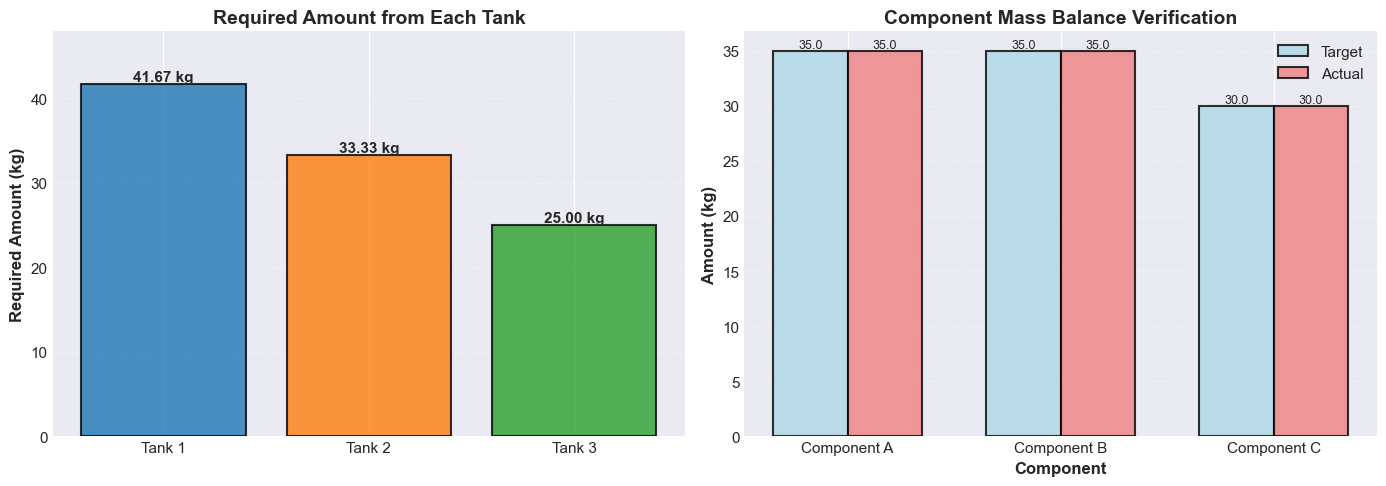


✓ 視覺化圖表已生成


In [9]:
# 視覺化結果
print("="*60)
print("視覺化結果")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ========== 子圖 1: 各槽用量 ==========
ax1 = axes[0]
tanks = ['Tank 1', 'Tank 2', 'Tank 3']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax1.bar(tanks, V, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

ax1.set_ylabel('Required Amount (kg)', fontsize=12, fontweight='bold')
ax1.set_title('Required Amount from Each Tank', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(0, max(V) * 1.15)

# 在長條上標註數值
for bar, val in zip(bars, V):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f} kg',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# ========== 子圖 2: 成分組成驗證 ==========
ax2 = axes[1]
components = ['Component A', 'Component B', 'Component C']
target_amounts = [35, 35, 30]
actual_amounts = [actual_A, actual_B, actual_C]

x = np.arange(len(components))
width = 0.35

bars1 = ax2.bar(x - width/2, target_amounts, width, label='Target', 
                color='lightblue', edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax2.bar(x + width/2, actual_amounts, width, label='Actual', 
                color='lightcoral', edgecolor='black', linewidth=1.5, alpha=0.8)

ax2.set_xlabel('Component', fontsize=12, fontweight='bold')
ax2.set_ylabel('Amount (kg)', fontsize=12, fontweight='bold')
ax2.set_title('Component Mass Balance Verification', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(components)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# 標註數值
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ 視覺化圖表已生成")

---
## 8. 總結

### 重點回顧

**1. 問題建模**
- 從實際化工問題建立物料平衡方程式
- 將物料平衡轉化為線性聯立方程組 $\mathbf{Ax} = \mathbf{b}$
- 識別系統類型（過確定系統：4 個方程式，3 個未知數）

**2. 求解方法**
- NumPy: `np.linalg.lstsq()` 求最小平方解
- SciPy: `scipy.linalg.lstsq()` 提供相同功能
- 兩種方法結果一致，驗證正確性

**3. 解的驗證**
- **秩分析**：判斷解的存在性與唯一性（ $\mathrm{rank}(\mathbf{A}) = \mathrm{rank}([\mathbf{A} \mid \mathbf{b}]) = 3$ ）
- **殘差檢查**：確認解的精確度（殘差 ≈ 0）
- **物理性檢查**：確認解的實際可行性（所有用量 $\geq 0$ ）
- **質量守恆**：驗證物料平衡（誤差 < 10⁻¹⁰）

**4. 數值穩定性**
- 條件數分析：評估系統的病態程度
- 本問題條件數小，系統數值穩定

### 學習成果

完成本範例後，您已學會：

✓ 建立化工問題的物料平衡方程式  
✓ 將實際問題轉化為矩陣形式  
✓ 使用 NumPy 與 SciPy 求解過確定系統  
✓ 驗證解的正確性與物理意義  
✓ 評估數值穩定性  

### 延伸思考

1. **如果某個槽的庫存不足怎麼辦？**  
   需要增加不等式約束 $V_i \leq V_{i,\max}$ ，轉化為線性規劃問題

2. **如果目標組成無法精確達成怎麼辦？**  
   使用最小平方法找到最接近的解，分析殘差

3. **如果有更多儲存槽可以選擇？**  
   增加決策變數，變成低確定系統，可能有無窮多組解

### 實際應用

液體摻合問題廣泛應用於：

- 🛢️ **石油煉製**：調配不同規格的汽油、柴油
- 🎨 **塗料工業**：混合顏料達到特定色彩
- 🥤 **飲料製造**：調配飲料成分比例
- 💄 **化妝品產業**：混合原料達到配方要求

---

**本範例程式碼完成！**